<a href="https://colab.research.google.com/github/SalmiFatimaZahra/Gestion-des-salaires-des-employ-s-dans-une-entreprise-/blob/main/ComputerVisionMiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# IMPORTS
# =========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from pathlib import Path

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


In [ ]:
import zipfile
import os

zip_path = "/content/archive (8).zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extrait dans :", extract_path)
print(os.listdir(extract_path))

Dataset extrait dans : /content/data
['iitd_Dataset']


In [ ]:
# =========================
# VERIFIER LE CONTENU EXTRAIT
# =========================
for root, dirs, files_ in os.walk(extract_path):
    print("Dossier :", root)
    print("Sous-dossiers :", dirs[:5])
    print("Fichiers :", files_[:5])
    print("-" * 50)
    break

Dossier : /content/data
Sous-dossiers : ['iitd_Dataset']
Fichiers : []
--------------------------------------------------


In [ ]:
# =========================
# LISTER TOUTES LES IMAGES DU DATASET
# =========================
from pathlib import Path

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

all_images = []
for root, dirs, files_ in os.walk(extract_path):
    for f in files_:
        if Path(f).suffix.lower() in image_extensions:
            all_images.append(os.path.join(root, f))

print("Nombre total d'images trouvées :", len(all_images))

for p in all_images[:10]:
    print(p)

Nombre total d'images trouvées : 2240
/content/data/iitd_Dataset/images/141/07_R.bmp
/content/data/iitd_Dataset/images/141/01_L.bmp
/content/data/iitd_Dataset/images/141/10_R.bmp
/content/data/iitd_Dataset/images/141/06_R.bmp
/content/data/iitd_Dataset/images/141/05_L.bmp
/content/data/iitd_Dataset/images/141/09_R.bmp
/content/data/iitd_Dataset/images/141/08_R.bmp
/content/data/iitd_Dataset/images/141/02_L.bmp
/content/data/iitd_Dataset/images/141/03_L.bmp
/content/data/iitd_Dataset/images/141/04_L.bmp


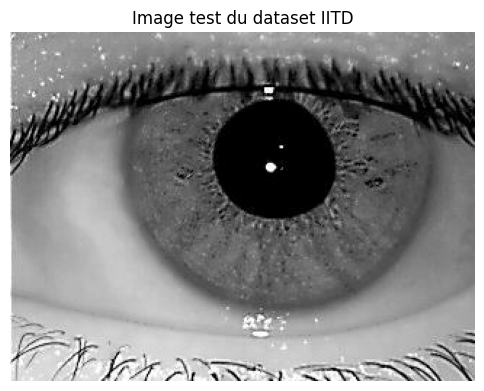

Image utilisée : /content/data/iitd_Dataset/images/141/07_R.bmp
Dimensions : (240, 320, 3)


In [ ]:
# =========================
# CHARGER ET AFFICHER UNE IMAGE TEST
# =========================
import cv2
import matplotlib.pyplot as plt

img_path = all_images[0]
img_bgr = cv2.imread(img_path)

if img_bgr is None:
    raise ValueError(f"Impossible de lire l'image : {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Image test du dataset IITD")
plt.axis("off")
plt.show()

print("Image utilisée :", img_path)
print("Dimensions :", img_bgr.shape)

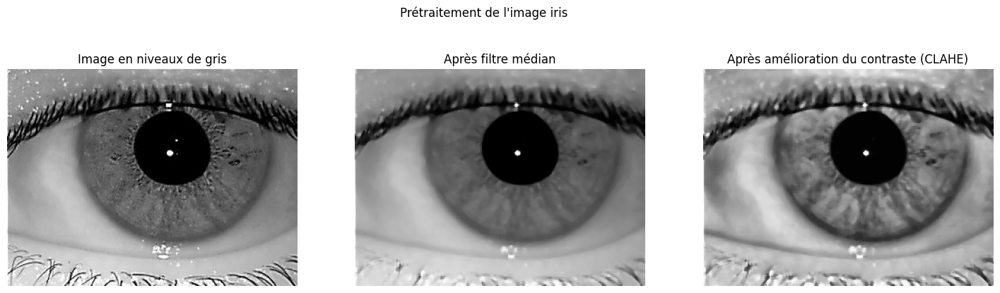

Image utilisée : /content/data/iitd_Dataset/images/141/07_R.bmp
Taille image : (240, 320)
Type : uint8


In [ ]:
# =========================
# PRETRAITEMENT DE L'IMAGE
# =========================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Charger l'image choisie
img_path = all_images[0]   # tu peux changer l'index plus tard
img_bgr = cv2.imread(img_path)

# Vérification de sécurité
if img_bgr is None:
    raise ValueError(f"Impossible de lire l'image : {img_path}")

# 2) Conversion en niveaux de gris
# Même si l'image semble déjà grise, OpenCV peut la lire sur 3 canaux
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 3) Réduction du bruit avec un filtre médian
# Très utile pour supprimer le petit bruit sans trop déformer les contours
gray_blur = cv2.medianBlur(gray, 5)

# 4) Amélioration du contraste local avec CLAHE
# CLAHE = Contrast Limited Adaptive Histogram Equalization
# Cela permet de mieux faire ressortir la texture de l'iris
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(gray_blur)

# 5) Affichage comparatif des résultats
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].imshow(gray, cmap='gray')
ax[0].set_title("Image en niveaux de gris")
ax[0].axis("off")

ax[1].imshow(gray_blur, cmap='gray')
ax[1].set_title("Après filtre médian")
ax[1].axis("off")

ax[2].imshow(gray_clahe, cmap='gray')
ax[2].set_title("Après amélioration du contraste (CLAHE)")
ax[2].axis("off")

plt.suptitle("Prétraitement de l'image iris")
plt.show()

# 6) Afficher quelques infos utiles
print("Image utilisée :", img_path)
print("Taille image :", gray.shape)
print("Type :", gray.dtype)

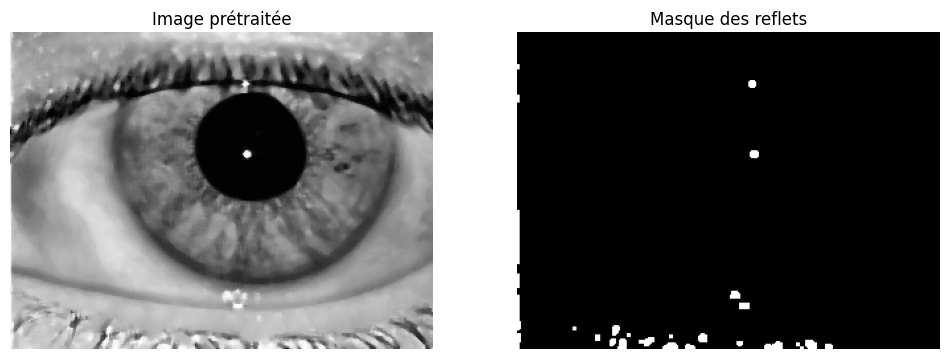

In [ ]:
# =========================
# DETECTION DES REFLETS SPECULAIRES
# =========================

# Les reflets sont des zones très lumineuses
# On applique un seuil haut pour les isoler
_, spec_mask = cv2.threshold(gray_clahe, 240, 255, cv2.THRESH_BINARY)

# On dilate légèrement le masque pour couvrir toute la tache brillante
kernel = np.ones((3, 3), np.uint8)
spec_mask = cv2.dilate(spec_mask, kernel, iterations=1)

# Affichage
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(gray_clahe, cmap='gray')
ax[0].set_title("Image prétraitée")
ax[0].axis("off")

ax[1].imshow(spec_mask, cmap='gray')
ax[1].set_title("Masque des reflets")
ax[1].axis("off")

plt.show()

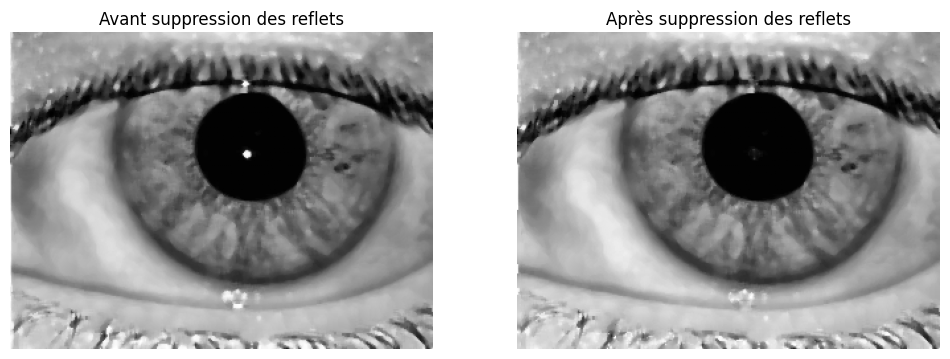

In [ ]:
# =========================
# CORRECTION DES REFLETS PAR INPAINTING
# =========================

gray_inpaint = cv2.inpaint(gray_clahe, spec_mask, 3, cv2.INPAINT_TELEA)

# Affichage avant / après
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(gray_clahe, cmap='gray')
ax[0].set_title("Avant suppression des reflets")
ax[0].axis("off")

ax[1].imshow(gray_inpaint, cmap='gray')
ax[1].set_title("Après suppression des reflets")
ax[1].axis("off")

plt.show()

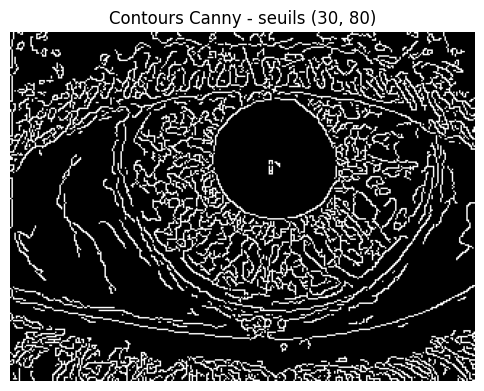

In [ ]:
# =========================
# DETECTION DES CONTOURS AVEC CANNY
# =========================

# Seuils à tester
low_thresh = 30
high_thresh = 80

edges = cv2.Canny(gray_inpaint, low_thresh, high_thresh)

plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap='gray')
plt.title(f"Contours Canny - seuils ({low_thresh}, {high_thresh})")
plt.axis("off")
plt.show()

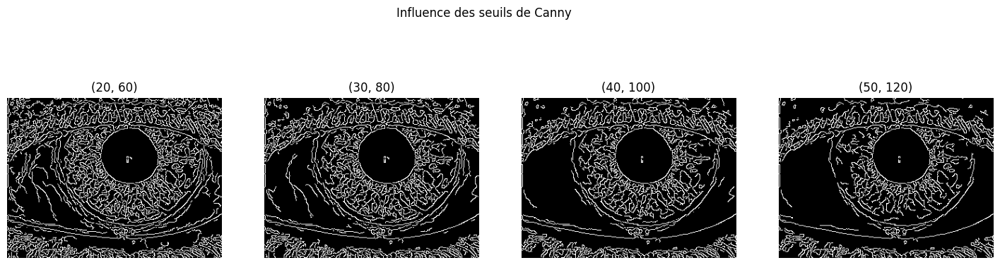

In [ ]:
# =========================
# TEST DE PLUSIEURS SEUILS CANNY
# =========================

threshold_pairs = [(20, 60), (30, 80), (40, 100), (50, 120)]

fig, ax = plt.subplots(1, len(threshold_pairs), figsize=(18, 5))

for i, (low, high) in enumerate(threshold_pairs):
    ed = cv2.Canny(gray_inpaint, low, high)
    ax[i].imshow(ed, cmap='gray')
    ax[i].set_title(f"({low}, {high})")
    ax[i].axis("off")

plt.suptitle("Influence des seuils de Canny")
plt.show()

In [ ]:
low_thresh = 30
high_thresh = 80

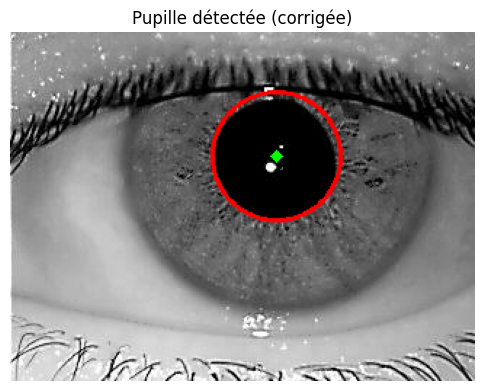

Pupille détectée : (np.int64(183), np.int64(85), np.int64(44))


In [ ]:
# =========================
# DETECTION DE LA PUPILLE (CORRIGEE)
# =========================

work_img = gray_inpaint.copy()

pupil_circles = cv2.HoughCircles(
    work_img,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=15,     # ↓ plus sensible
    minRadius=20,  # 👈 IMPORTANT
    maxRadius=50   # 👈 IMPORTANT (réduit fortement)
)

img_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

best_pupil = None

# Fonction pour choisir le cercle le plus sombre
def mean_intensity(image, x, y, r):
    mask = np.zeros_like(image, dtype=np.uint8)
    cv2.circle(mask, (x, y), r, 255, -1)
    return np.mean(image[mask == 255])

if pupil_circles is not None:
    pupil_circles = np.round(pupil_circles[0, :]).astype(int)

    best_score = 1e9

    for (x, y, r) in pupil_circles:
        score = mean_intensity(gray_inpaint, x, y, r)

        # On choisit le cercle le plus sombre
        if score < best_score:
            best_score = score
            best_pupil = (x, y, r)

# Dessin du meilleur cercle
if best_pupil is not None:
    x, y, r = best_pupil
    cv2.circle(img_vis, (x, y), r, (255, 0, 0), 2)
    cv2.circle(img_vis, (x, y), 2, (0, 255, 0), 3)

plt.figure(figsize=(6,6))
plt.imshow(img_vis)
plt.title("Pupille détectée (corrigée)")
plt.axis("off")
plt.show()

print("Pupille détectée :", best_pupil)

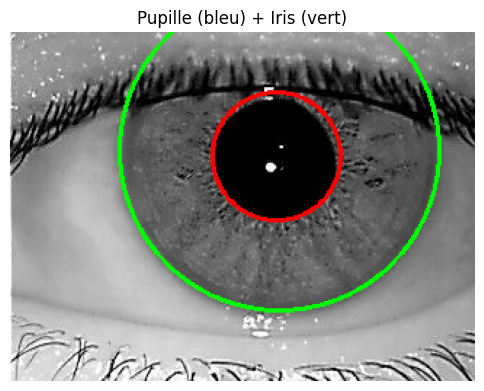

Pupille : (np.int64(183), np.int64(85), np.int64(44))
Iris : (np.int64(185), np.int64(81), np.int64(110))


In [ ]:
# =========================
# DETECTION DE L'IRIS
# =========================

work_img = gray_inpaint.copy()

iris_circles = cv2.HoughCircles(
    work_img,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=100,
    param2=30,
    minRadius=80,   # 👈 plus grand que la pupille
    maxRadius=160
)

img_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

best_iris = None

if iris_circles is not None and best_pupil is not None:
    iris_circles = np.round(iris_circles[0, :]).astype(int)

    px, py, pr = best_pupil

    best_score = 1e9

    for (x, y, r) in iris_circles:

        # On ignore les cercles trop petits
        if r <= pr:
            continue

        # Distance centre pupille - centre cercle
        dist = np.sqrt((x - px)**2 + (y - py)**2)

        # On préfère les cercles proches de la pupille
        if dist < best_score:
            best_score = dist
            best_iris = (x, y, r)

# Dessin
if best_iris is not None:
    x, y, r = best_iris
    cv2.circle(img_vis, (x, y), r, (0, 255, 0), 2)

# Dessiner aussi la pupille pour vérifier
if best_pupil is not None:
    x, y, r = best_pupil
    cv2.circle(img_vis, (x, y), r, (255, 0, 0), 2)

plt.figure(figsize=(6,6))
plt.imshow(img_vis)
plt.title("Pupille (bleu) + Iris (vert)")
plt.axis("off")
plt.show()

print("Pupille :", best_pupil)
print("Iris :", best_iris)

In [ ]:
# =========================
# NORMALISATION RUBBER SHEET
# =========================

def rubber_sheet_normalization(image, pupil_circle, iris_circle, radial_res=64, angular_res=256):

    xp, yp, rp = pupil_circle
    xi, yi, ri = iris_circle

    # Image de sortie
    normalized = np.zeros((radial_res, angular_res), dtype=np.uint8)

    # Angles de 0 à 2π
    theta_values = np.linspace(0, 2*np.pi, angular_res)

    for t_idx, theta in enumerate(theta_values):

        # Point sur la pupille
        x_p = xp + rp * np.cos(theta)
        y_p = yp + rp * np.sin(theta)

        # Point sur l'iris
        x_i = xi + ri * np.cos(theta)
        y_i = yi + ri * np.sin(theta)

        for r_idx in range(radial_res):

            # interpolation entre pupille et iris
            alpha = r_idx / (radial_res - 1)

            x = (1 - alpha) * x_p + alpha * x_i
            y = (1 - alpha) * y_p + alpha * y_i

            x_int = int(round(x))
            y_int = int(round(y))

            # Vérifier limites
            if 0 <= x_int < image.shape[1] and 0 <= y_int < image.shape[0]:
                normalized[r_idx, t_idx] = image[y_int, x_int]

    return normalized

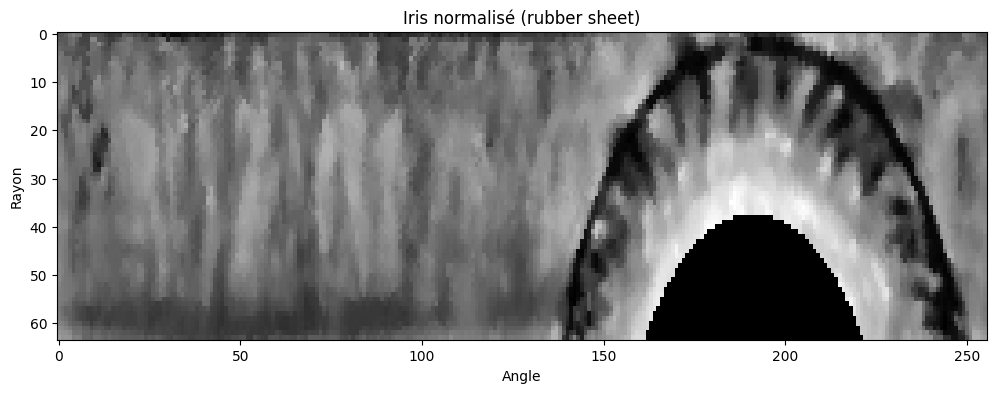

In [ ]:
# =========================
# APPLICATION
# =========================

norm_iris = rubber_sheet_normalization(
    gray_inpaint,
    best_pupil,
    best_iris,
    radial_res=64,
    angular_res=256
)

plt.figure(figsize=(12,4))
plt.imshow(norm_iris, cmap='gray', aspect='auto')
plt.title("Iris normalisé (rubber sheet)")
plt.xlabel("Angle")
plt.ylabel("Rayon")
plt.show()

In [ ]:
# =========================
# ENCODAGE DE L'IRIS (GABOR)
# =========================

def iris_code_gabor(normalized_iris):

    # Paramètres du filtre
    ksize = (21, 21)
    sigma = 4.0
    theta = 0
    lambd = 10.0
    gamma = 0.5
    psi = 0

    # Création du filtre de Gabor
    gabor_kernel = cv2.getGaborKernel(
        ksize, sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F
    )

    # Filtrage
    response = cv2.filter2D(normalized_iris, cv2.CV_32F, gabor_kernel)

    # Binarisation (très important)
    iris_code = (response > 0).astype(np.uint8)

    return response, iris_code

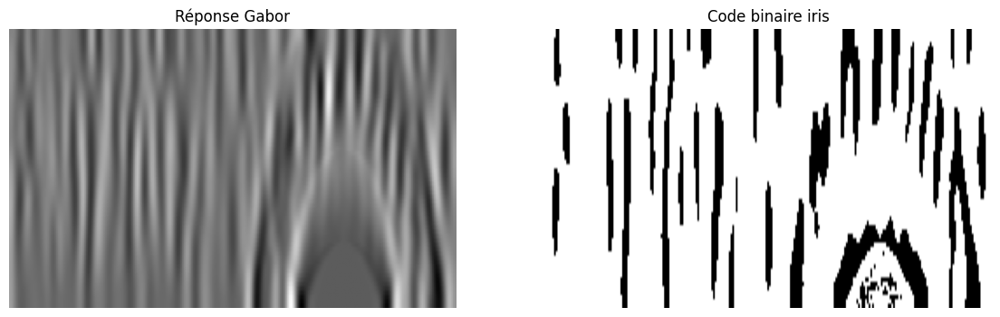

In [ ]:
# =========================
# APPLICATION DU CODE IRIS
# =========================

gabor_response, iris_code = iris_code_gabor(norm_iris)

fig, ax = plt.subplots(1, 2, figsize=(14,4))

ax[0].imshow(gabor_response, cmap='gray', aspect='auto')
ax[0].set_title("Réponse Gabor")
ax[0].axis("off")

ax[1].imshow(iris_code, cmap='gray', aspect='auto')
ax[1].set_title("Code binaire iris")
ax[1].axis("off")

plt.show()

In [ ]:
# =========================
# DISTANCE DE HAMMING
# =========================

def hamming_distance(code1, code2):
    return np.sum(code1 != code2) / code1.size

# Phase B — Traitement automatique de toute la base

In [ ]:
# =========================
# DOSSIERS DE SORTIE
# =========================
import os

output_dir = "/content/resultats_iitd"
norm_dir = os.path.join(output_dir, "normalized")
mask_dir = os.path.join(output_dir, "masks")
code_dir = os.path.join(output_dir, "codes")

os.makedirs(norm_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)
os.makedirs(code_dir, exist_ok=True)

print("Dossiers créés.")

Dossiers créés.


In [ ]:
# =========================
# NORMALISATION D'UN MASQUE
# =========================

def rubber_sheet_mask(mask, pupil_circle, iris_circle, radial_res=64, angular_res=256):
    xp, yp, rp = pupil_circle
    xi, yi, ri = iris_circle

    normalized_mask = np.zeros((radial_res, angular_res), dtype=np.uint8)
    theta_values = np.linspace(0, 2*np.pi, angular_res, endpoint=False)

    for t_idx, theta in enumerate(theta_values):
        x_p = xp + rp * np.cos(theta)
        y_p = yp + rp * np.sin(theta)

        x_i = xi + ri * np.cos(theta)
        y_i = yi + ri * np.sin(theta)

        for r_idx in range(radial_res):
            alpha = r_idx / (radial_res - 1)

            x = (1 - alpha) * x_p + alpha * x_i
            y = (1 - alpha) * y_p + alpha * y_i

            x_int = int(round(x))
            y_int = int(round(y))

            if 0 <= x_int < mask.shape[1] and 0 <= y_int < mask.shape[0]:
                normalized_mask[r_idx, t_idx] = mask[y_int, x_int]

    return normalized_mask

In [ ]:
# =========================
# FONCTION UTILE : INTENSITE MOYENNE DANS UN CERCLE
# =========================

import numpy as np
import cv2

def mean_intensity_in_circle(image, cx, cy, r):
    """
    Calcule l'intensité moyenne des pixels à l'intérieur d'un cercle.
    Cette fonction est utilisée pour choisir la pupille,
    car la pupille est normalement la zone la plus sombre.
    """
    mask = np.zeros_like(image, dtype=np.uint8)
    cv2.circle(mask, (cx, cy), r, 255, -1)

    values = image[mask == 255]

    if len(values) == 0:
        return 255

    return np.mean(values)

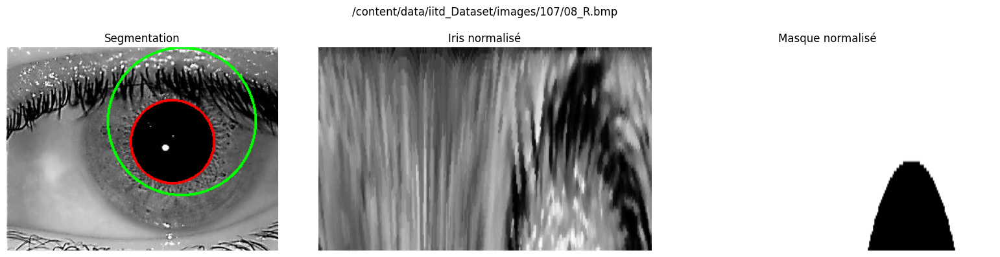

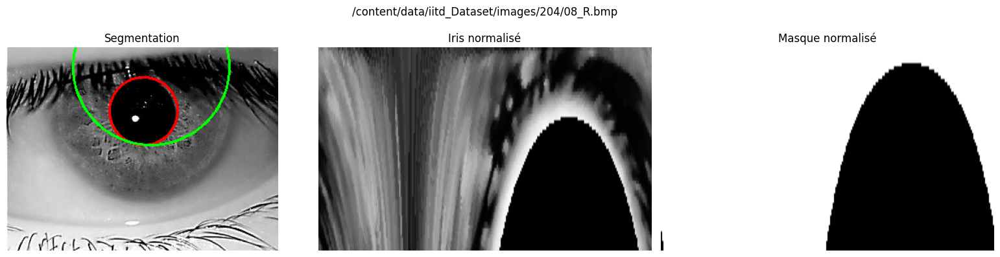

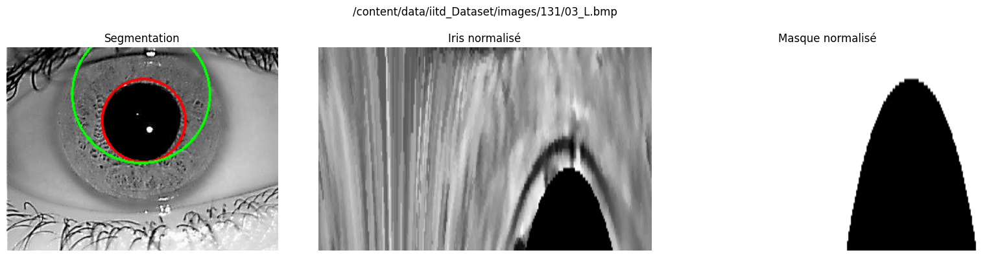

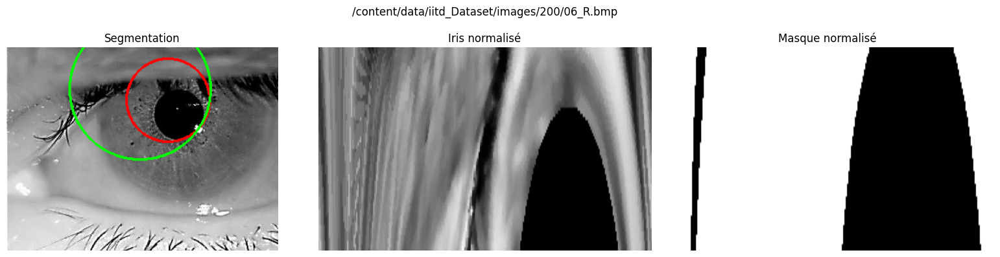

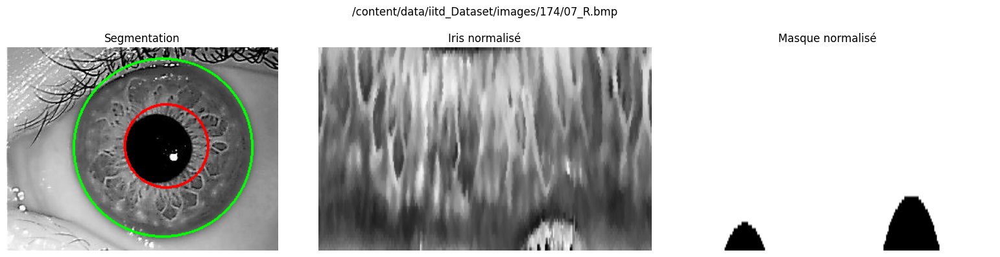

Image 1 : /content/data/iitd_Dataset/images/141/07_R.bmp
Image 2 : /content/data/iitd_Dataset/images/141/01_L.bmp
Distance de Hamming simple : 0.2838134765625
Distance de Hamming masquée : 0.19958644250651802


In [ ]:
# =========================================================
# PIPELINE COMPLET IRIS IITD - VERSION EN UN SEUL BLOC
# =========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# =========================================================
# 1) FONCTION : INTENSITE MOYENNE DANS UN CERCLE
# =========================================================
def mean_intensity_in_circle(image, cx, cy, r):
    """
    Calcule l'intensité moyenne des pixels à l'intérieur d'un cercle.
    Utile pour choisir la pupille, car la pupille est normalement sombre.
    """
    mask = np.zeros_like(image, dtype=np.uint8)
    cv2.circle(mask, (cx, cy), r, 255, -1)

    values = image[mask == 255]

    if len(values) == 0:
        return 255

    return np.mean(values)


# =========================================================
# 2) FONCTION : NORMALISATION RUBBER SHEET
# =========================================================
def rubber_sheet_normalization(image, pupil_circle, iris_circle, radial_res=64, angular_res=256):
    """
    Transforme l'anneau iris en image rectangulaire.
    """
    xp, yp, rp = pupil_circle
    xi, yi, ri = iris_circle

    normalized = np.zeros((radial_res, angular_res), dtype=np.uint8)

    theta_values = np.linspace(0, 2 * np.pi, angular_res, endpoint=False)

    for t_idx, theta in enumerate(theta_values):
        # Point sur le contour de la pupille
        x_p = xp + rp * np.cos(theta)
        y_p = yp + rp * np.sin(theta)

        # Point sur le contour externe de l'iris
        x_i = xi + ri * np.cos(theta)
        y_i = yi + ri * np.sin(theta)

        for r_idx in range(radial_res):
            alpha = r_idx / (radial_res - 1)

            # Interpolation entre pupille et iris
            x = (1 - alpha) * x_p + alpha * x_i
            y = (1 - alpha) * y_p + alpha * y_i

            x_int = int(round(x))
            y_int = int(round(y))

            if 0 <= x_int < image.shape[1] and 0 <= y_int < image.shape[0]:
                normalized[r_idx, t_idx] = image[y_int, x_int]

    return normalized


# =========================================================
# 3) FONCTION : NORMALISATION DU MASQUE
# =========================================================
def rubber_sheet_mask(mask, pupil_circle, iris_circle, radial_res=64, angular_res=256):
    """
    Applique la même normalisation à un masque binaire.
    """
    xp, yp, rp = pupil_circle
    xi, yi, ri = iris_circle

    normalized_mask = np.zeros((radial_res, angular_res), dtype=np.uint8)

    theta_values = np.linspace(0, 2 * np.pi, angular_res, endpoint=False)

    for t_idx, theta in enumerate(theta_values):
        x_p = xp + rp * np.cos(theta)
        y_p = yp + rp * np.sin(theta)

        x_i = xi + ri * np.cos(theta)
        y_i = yi + ri * np.sin(theta)

        for r_idx in range(radial_res):
            alpha = r_idx / (radial_res - 1)

            x = (1 - alpha) * x_p + alpha * x_i
            y = (1 - alpha) * y_p + alpha * y_i

            x_int = int(round(x))
            y_int = int(round(y))

            if 0 <= x_int < mask.shape[1] and 0 <= y_int < mask.shape[0]:
                normalized_mask[r_idx, t_idx] = mask[y_int, x_int]

    return normalized_mask


# =========================================================
# 4) FONCTION : ENCODAGE GABOR
# =========================================================
def iris_code_gabor(normalized_iris):
    """
    Encode l'iris avec un filtre de Gabor puis binarise la réponse.
    """
    ksize = (21, 21)
    sigma = 4.0
    theta = 0
    lambd = 10.0
    gamma = 0.5
    psi = 0

    gabor_kernel = cv2.getGaborKernel(
        ksize, sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F
    )

    response = cv2.filter2D(normalized_iris, cv2.CV_32F, gabor_kernel)

    iris_code = (response > 0).astype(np.uint8)

    return response, iris_code


# =========================================================
# 5) FONCTION : DISTANCE DE HAMMING
# =========================================================
def hamming_distance(code1, code2):
    """
    Distance de Hamming simple entre deux codes binaires.
    """
    return np.sum(code1 != code2) / code1.size


# =========================================================
# 6) FONCTION : DISTANCE DE HAMMING MASQUEE
# =========================================================
def hamming_distance_masked(code1, mask1, code2, mask2):
    """
    Compare deux codes binaires uniquement sur les zones fiables.
    """
    valid = (mask1 > 0) & (mask2 > 0)

    if np.sum(valid) == 0:
        return 1.0

    diff = (code1[valid] != code2[valid])
    return np.sum(diff) / np.sum(valid)


# =========================================================
# 7) FONCTION : PIPELINE COMPLET D'UNE IMAGE
# =========================================================
def process_iris_image(img_path, radial_res=64, angular_res=256):
    """
    Pipeline complet :
    - lecture image
    - prétraitement
    - détection pupille
    - détection iris
    - masque fiable
    - normalisation
    - encodage
    """
    img_bgr = cv2.imread(img_path)

    if img_bgr is None:
        raise ValueError(f"Impossible de lire l'image : {img_path}")

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # -------------------------
    # Prétraitement
    # -------------------------
    gray_blur = cv2.medianBlur(gray, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray_blur)

    # -------------------------
    # Détection des reflets
    # -------------------------
    _, spec_mask = cv2.threshold(gray_clahe, 240, 255, cv2.THRESH_BINARY)
    spec_mask = cv2.dilate(spec_mask, np.ones((3, 3), np.uint8), iterations=1)

    # Correction des reflets
    gray_inpaint = cv2.inpaint(gray_clahe, spec_mask, 3, cv2.INPAINT_TELEA)

    # -------------------------
    # Détection de la pupille
    # -------------------------
    pupil_circles = cv2.HoughCircles(
        gray_inpaint,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=50,
        param1=100,
        param2=15,
        minRadius=20,
        maxRadius=50
    )

    if pupil_circles is None:
        raise ValueError("Aucune pupille détectée")

    pupil_circles = np.round(pupil_circles[0, :]).astype(int)

    best_pupil = None
    best_score = 1e9

    for (x, y, r) in pupil_circles:
        score = mean_intensity_in_circle(gray_inpaint, x, y, r)

        if score < best_score:
            best_score = score
            best_pupil = (x, y, r)

    # -------------------------
    # Détection de l'iris
    # -------------------------
    iris_circles = cv2.HoughCircles(
        gray_inpaint,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=80,
        param1=100,
        param2=30,
        minRadius=80,
        maxRadius=160
    )

    if iris_circles is None:
        raise ValueError("Aucun iris détecté")

    iris_circles = np.round(iris_circles[0, :]).astype(int)

    px, py, pr = best_pupil
    best_iris = None
    best_score = 1e9

    for (x, y, r) in iris_circles:
        # L'iris doit être plus grand que la pupille
        if r <= pr:
            continue

        # Distance entre le centre de l'iris et celui de la pupille
        center_dist = np.sqrt((x - px)**2 + (y - py)**2)

        # Pénalité sur le rayon pour favoriser une taille plausible
        radius_penalty = abs(r - 105)

        # Score final : on favorise surtout la quasi-concentricité
        score = 2.0 * center_dist + 0.2 * radius_penalty

        if score < best_score:
            best_score = score
            best_iris = (x, y, r)

    if best_iris is None:
        raise ValueError("Aucun iris valide détecté")

    # -------------------------
    # Masque des zones fiables
    # -------------------------
    h, w = gray_inpaint.shape
    occlusion_mask = np.ones((h, w), dtype=np.uint8) * 255

    # On supprime une bande haute et basse
    occlusion_mask[:int(0.12 * h), :] = 0
    occlusion_mask[int(0.90 * h):, :] = 0

    # On retire aussi les reflets
    reliable_mask = cv2.bitwise_and(occlusion_mask, cv2.bitwise_not(spec_mask))

    # -------------------------
    # Normalisation
    # -------------------------
    norm_iris = rubber_sheet_normalization(
        gray_inpaint,
        best_pupil,
        best_iris,
        radial_res=radial_res,
        angular_res=angular_res
    )

    norm_mask = rubber_sheet_mask(
        reliable_mask,
        best_pupil,
        best_iris,
        radial_res=radial_res,
        angular_res=angular_res
    )

    # -------------------------
    # Encodage
    # -------------------------
    _, iris_code = iris_code_gabor(norm_iris)

    return {
        "pupil": best_pupil,
        "iris": best_iris,
        "norm_iris": norm_iris,
        "norm_mask": norm_mask,
        "iris_code": iris_code
    }


# =========================================================
# 8) VISUALISATION DE QUELQUES IMAGES ALEATOIRES
# =========================================================
sample_paths = random.sample(all_images, 5)

for img_path in sample_paths:
    try:
        res = process_iris_image(img_path)

        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_vis = img_rgb.copy()

        pupil = res["pupil"]
        iris = res["iris"]

        # Pupille en rouge
        cv2.circle(img_vis, (pupil[0], pupil[1]), pupil[2], (255, 0, 0), 2)

        # Iris en vert
        cv2.circle(img_vis, (iris[0], iris[1]), iris[2], (0, 255, 0), 2)

        fig, ax = plt.subplots(1, 3, figsize=(16, 4))

        ax[0].imshow(img_vis)
        ax[0].set_title("Segmentation")
        ax[0].axis("off")

        ax[1].imshow(res["norm_iris"], cmap="gray", aspect="auto")
        ax[1].set_title("Iris normalisé")
        ax[1].axis("off")

        ax[2].imshow(res["norm_mask"], cmap="gray", aspect="auto")
        ax[2].set_title("Masque normalisé")
        ax[2].axis("off")

        plt.suptitle(img_path)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("Erreur sur", img_path, "->", e)


# =========================================================
# 9) EXEMPLE DE COMPARAISON ENTRE DEUX IMAGES
# =========================================================
# Même personne / même œil si possible
img1 = all_images[0]
img2 = all_images[1]

res1 = process_iris_image(img1)
res2 = process_iris_image(img2)

hd_simple = hamming_distance(res1["iris_code"], res2["iris_code"])
hd_masked = hamming_distance_masked(
    res1["iris_code"], res1["norm_mask"],
    res2["iris_code"], res2["norm_mask"]
)

print("Image 1 :", img1)
print("Image 2 :", img2)
print("Distance de Hamming simple :", hd_simple)
print("Distance de Hamming masquée :", hd_masked)

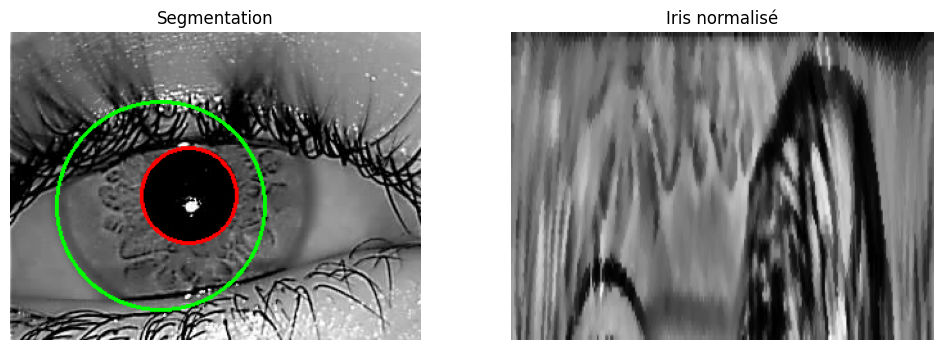

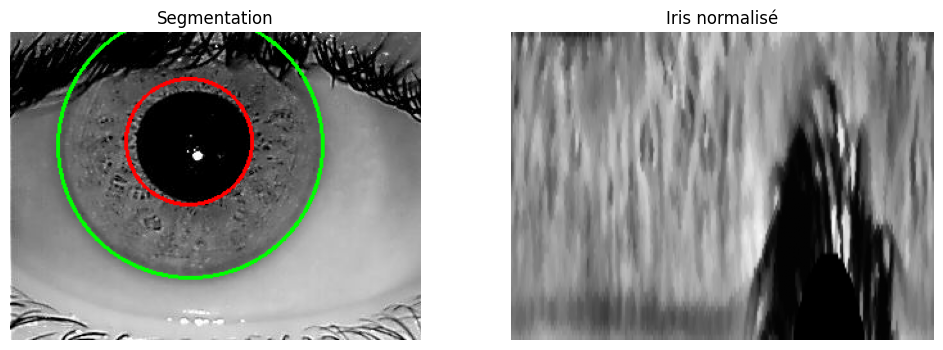

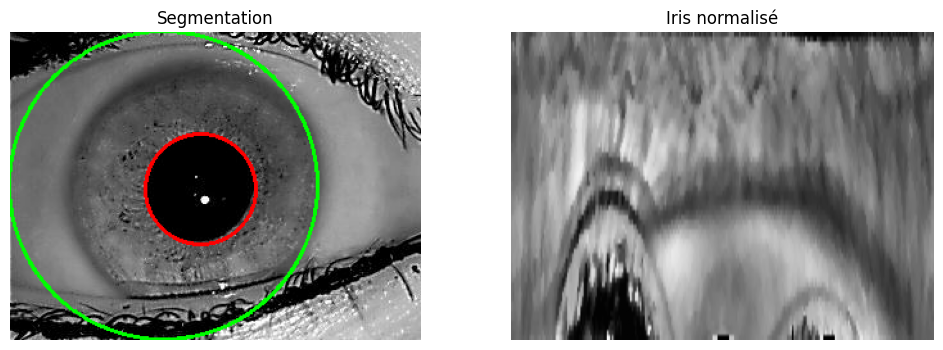

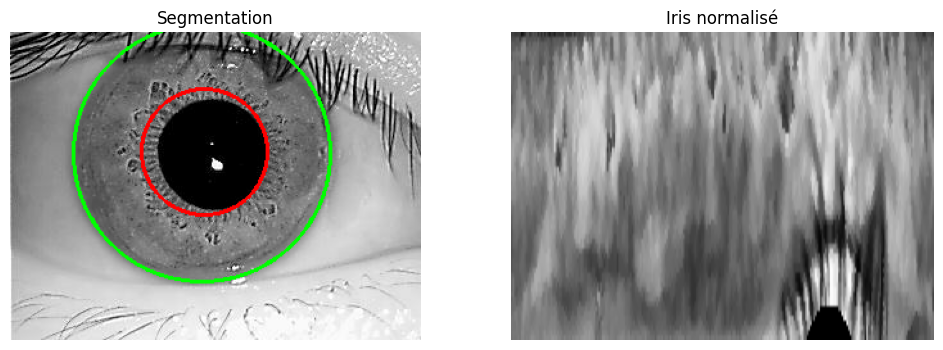

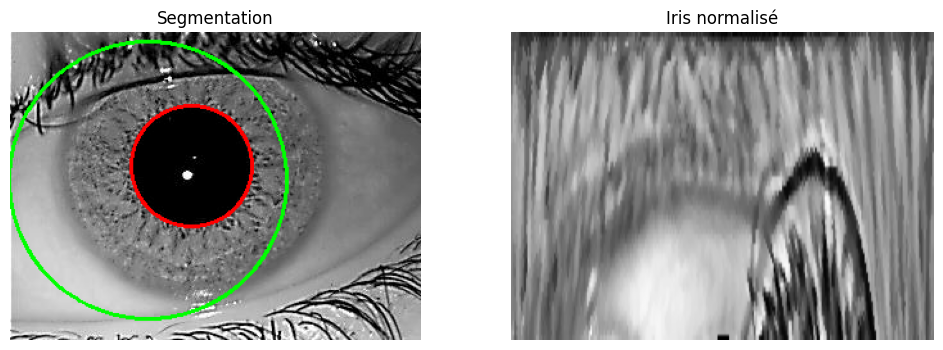

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2

sample_paths = random.sample(all_images, 5)

for img_path in sample_paths:
    res = process_iris_image(img_path)

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = img_rgb.copy()

    pupil = res["pupil"]
    iris = res["iris"]

    cv2.circle(img_vis, (pupil[0], pupil[1]), pupil[2], (255, 0, 0), 2)
    cv2.circle(img_vis, (iris[0], iris[1]), iris[2], (0, 255, 0), 2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(img_vis)
    ax[0].set_title("Segmentation")
    ax[0].axis("off")

    ax[1].imshow(res["norm_iris"], cmap="gray", aspect="auto")
    ax[1].set_title("Iris normalisé")
    ax[1].axis("off")

    plt.show()

In [ ]:
# =========================
# TRAITEMENT DE TOUTES LES IMAGES
# =========================

results = []
errors = []

for i, img_path in enumerate(all_images):
    try:
        res = process_iris_image(img_path)

        # Nom de base sans extension
        base_name = os.path.splitext(os.path.basename(img_path))[0]

        # Sauvegardes
        cv2.imwrite(os.path.join(norm_dir, f"{base_name}_norm.png"), res["norm_iris"])
        cv2.imwrite(os.path.join(mask_dir, f"{base_name}_mask.png"), res["norm_mask"])


        # Sauvegarde du code sous forme numpy
        np.save(os.path.join(code_dir, f"{base_name}_code.npy"), res["iris_code"])

        results.append({
            "image": img_path,
            "pupil": res["pupil"],
            "iris": res["iris"]
        })

    except Exception as e:
        errors.append((img_path, str(e)))

    if (i + 1) % 100 == 0:
        print(f"{i+1} images traitées...")

print("Traitement terminé.")
print("Succès :", len(results))
print("Erreurs :", len(errors))

100 images traitées...
200 images traitées...
300 images traitées...
400 images traitées...
500 images traitées...
600 images traitées...
700 images traitées...
800 images traitées...
900 images traitées...
1000 images traitées...
1100 images traitées...
1200 images traitées...
1300 images traitées...
1400 images traitées...
1500 images traitées...
1600 images traitées...
1700 images traitées...
1800 images traitées...
1900 images traitées...
2000 images traitées...
2100 images traitées...
2200 images traitées...
Traitement terminé.
Succès : 2240
Erreurs : 0


In [ ]:
# =========================
# AFFICHER QUELQUES ERREURS
# =========================

for err in errors[:10]:
    print(err)

In [ ]:
# =========================
# EXEMPLE DE MATCHING
# =========================

img1 = "/content/data/iitd_Dataset/images/172/01_L.bmp"
img2 = "/content/data/iitd_Dataset/images/172/02_L.bmp"

res1 = process_iris_image(img1)
res2 = process_iris_image(img2)

hd = hamming_distance(res1["iris_code"], res2["iris_code"])

print("Image 1 :", img1)
print("Image 2 :", img2)
print("Distance de Hamming :", hd)

Image 1 : /content/data/iitd_Dataset/images/172/01_L.bmp
Image 2 : /content/data/iitd_Dataset/images/172/02_L.bmp
Distance de Hamming : 0.05255126953125


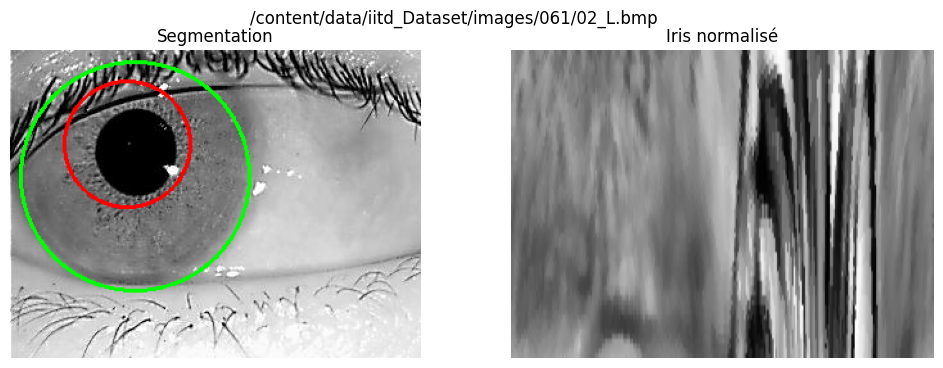

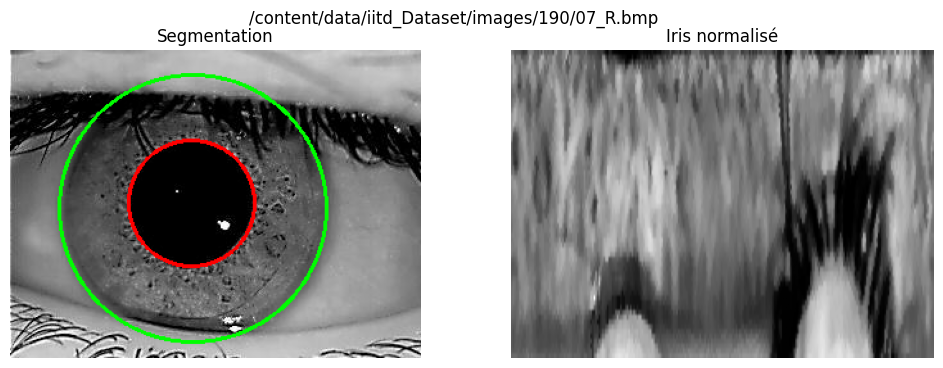

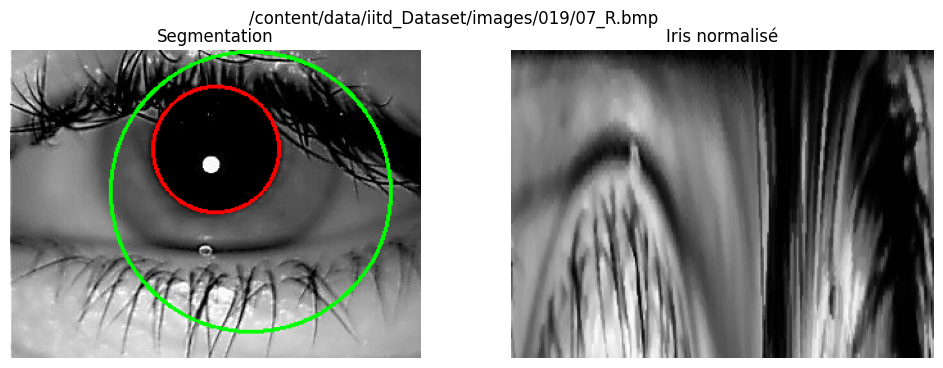

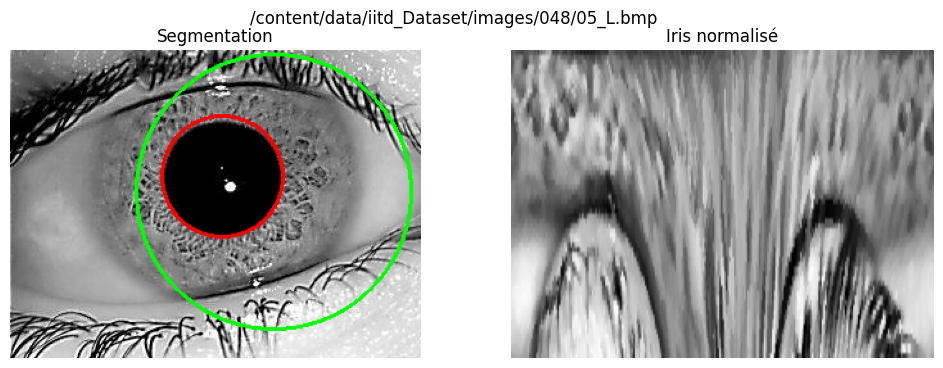

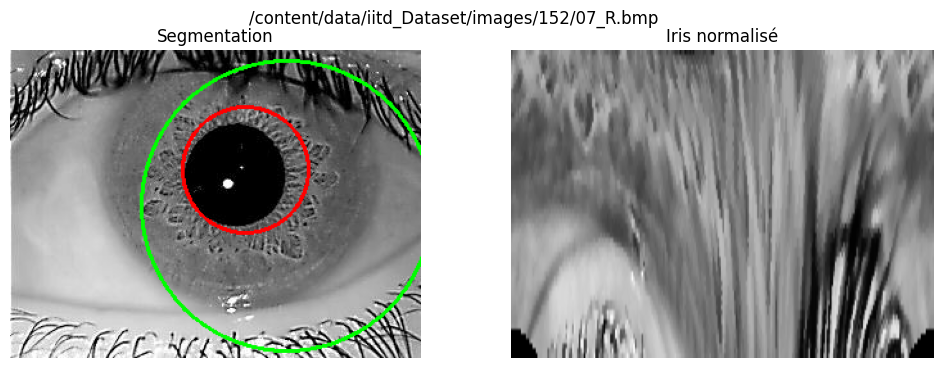

...

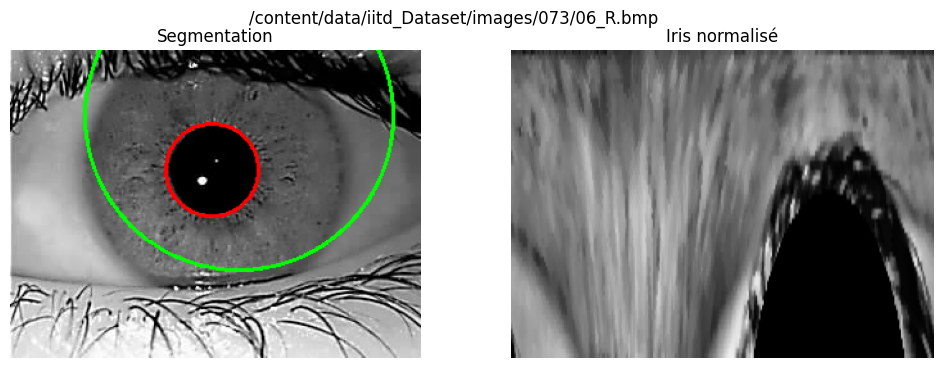

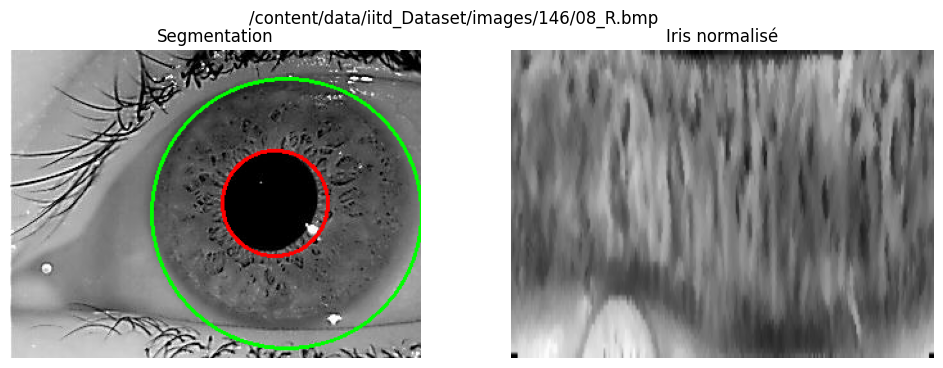

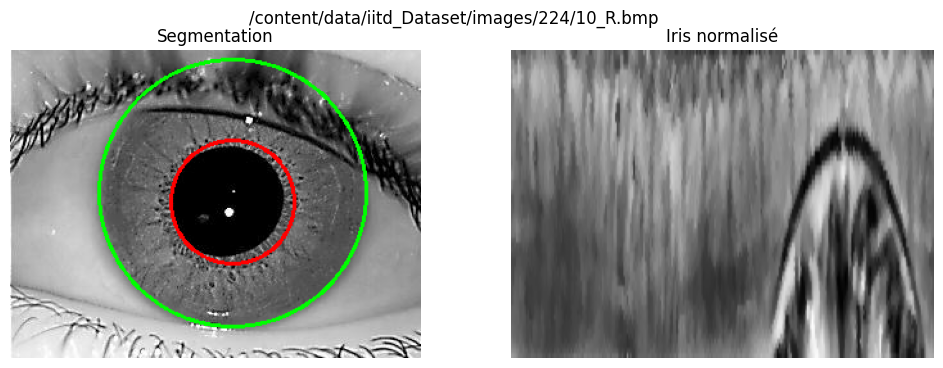

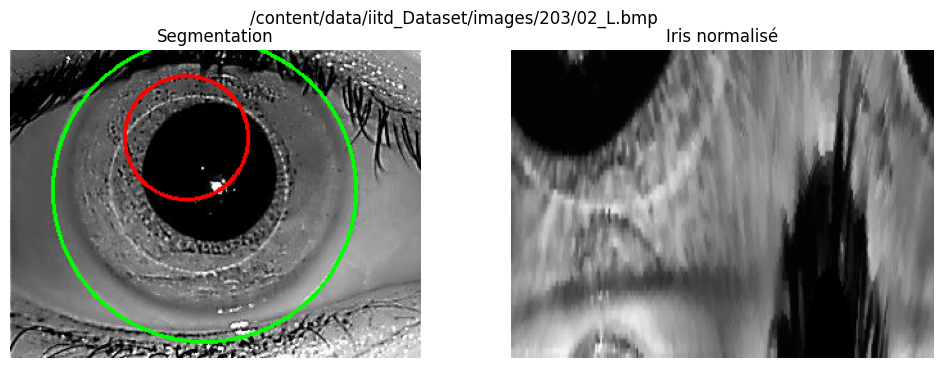

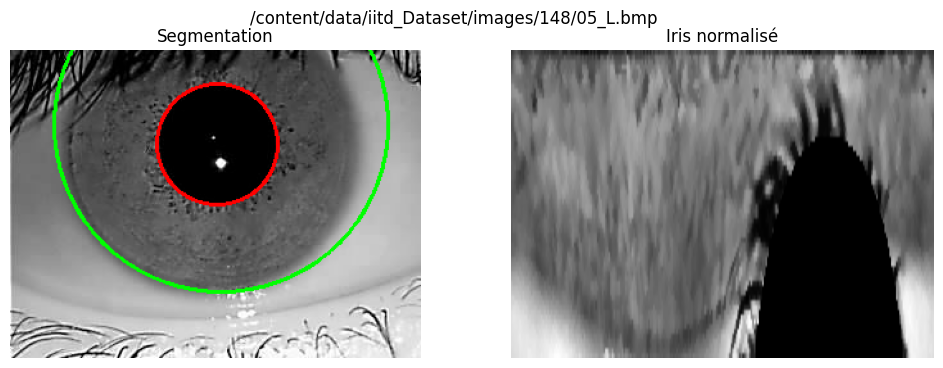

In [ ]:
# =========================
# VERIFICATION VISUELLE SUR QUELQUES IMAGES
# =========================

import random
import matplotlib.pyplot as plt

sample_paths = random.sample(all_images, 20)

for img_path in sample_paths:
    res = process_iris_image(img_path)

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pupil = res["pupil"]
    iris = res["iris"]

    img_vis = img_rgb.copy()

    # pupille en rouge
    cv2.circle(img_vis, (pupil[0], pupil[1]), pupil[2], (255, 0, 0), 2)

    # iris en vert
    cv2.circle(img_vis, (iris[0], iris[1]), iris[2], (0, 255, 0), 2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].imshow(img_vis)
    ax[0].set_title("Segmentation")
    ax[0].axis("off")

    ax[1].imshow(res["norm_iris"], cmap="gray", aspect="auto")
    ax[1].set_title("Iris normalisé")
    ax[1].axis("off")

    plt.suptitle(img_path)
    plt.show()

In [ ]:
# =========================
# COMPARAISON
# =========================

# même personne (exemple)
img1 = all_images[0]
img2 = all_images[1]

res1 = process_iris_image(img1)
res2 = process_iris_image(img2)

hd_same = hamming_distance(res1["iris_code"], res2["iris_code"])

print("Distance (même personne) :", hd_same)


# personnes différentes
img3 = all_images[0]
img4 = all_images[100]

res3 = process_iris_image(img3)
res4 = process_iris_image(img4)

hd_diff = hamming_distance(res3["iris_code"], res4["iris_code"])

print("Distance (personnes différentes) :", hd_diff)

Distance (même personne) : 0.2838134765625
Distance (personnes différentes) : 0.26043701171875
